# Blending degeneracies

[Woźniak and Paczyński (1997)](https://ui.adsabs.harvard.edu/abs/1997ApJ...487...55W/abstract) identified the degeneracies caused by a blended source star. 

In [1]:
from os import path
import copy
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import collections
from astropy import units as u
from pyLIMA import event
from pyLIMA import telescopes
from pyLIMA.models import PSPL_model
from pyLIMA.outputs import pyLIMA_plots
from pyLIMA import toolbox
from pyLIMA.simulations import simulator
from matplotlib.ticker import MaxNLocator

## Large impact parameters

The measured magnification is the ratio of the measured flux (F(t)) to the baseline flux (F_0).  

In [37]:
def calc_measured_magnification(t, u0, tE, fratio):
    F = 1 + ((2*fratio)/((u0**2 + (t/tE)**2)**2))
    return F

In [38]:
# Range of times to calculate; equations assume event peaks at t = 0
t = np.arange(-2.0, 2.0, 0.01)

In [39]:
# Case with no blending
u0_1 = 1.5
fratio_1 = 1.0
tE_1 = 1.0

A_no_blend = calc_measured_magnification(t, u0_1, tE_1, fratio_1)

In [55]:
# Case with blending
u0_2 = 1.4
fratio_2 = 0.75
tE_2 = 1.15

A_blend = calc_measured_magnification(t_tE, u0_2, tE_2, fratio_2)

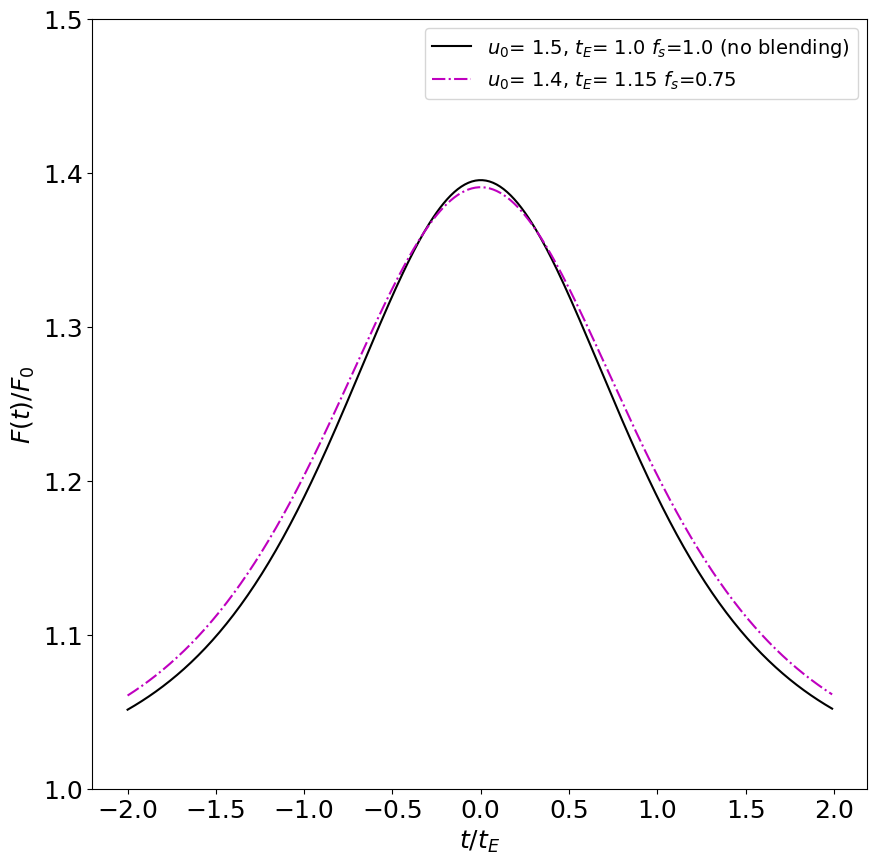

In [56]:
fig, axs = plt.subplots(1, 1, figsize=(10,10))

axs.plot(t, A_no_blend, 'k-', label='$u_{0}$= ' + str(u0_1) + ', $t_{E}$= ' + str(tE_1) + ' $f_{s}$=1.0 (no blending)')
axs.plot(t, A_blend, 'm-.', label='$u_{0}$= ' + str(u0_2) + ', $t_{E}$= ' + str(tE_2) + ' $f_{s}$='+str(fratio_2))

axs.set_xlabel('$t/t_{E}$', fontsize=18)
axs.set_ylabel('$F(t)/F_{0}$', fontsize=18)
axs.tick_params(axis='x', labelsize=18)
axs.tick_params(axis='y', labelsize=18)
axs.legend(loc='upper right', fontsize=14)

axs.set_ylim((1.0, 1.50))

plt.savefig('./blending_degen_large_u0.png')

## Source fainter than surrounding neighbors

In [17]:
def calc_measured_magnification2(t, u0, tE, fratio):
    F = 1 + ((fratio)/((u0**2 + (t/tE)**2)**0.5))
    return F

In [18]:
# Range of times to calculate; equations assume event peaks at t = 0
t = np.arange(-2.0, 2.0, 0.01)

In [20]:
u0_1 = 0.15
tE_1 = 1.0
fratio_1 = 0.07

A1 = calc_measured_magnification2(t, u0_1, tE_1, fratio_1)

In [23]:
u0_2 = 0.97
tE_2 = 0.3
fratio_2 = 1.0

A2 = calc_measured_magnification2(t, u0_1, tE_1, fratio_1)

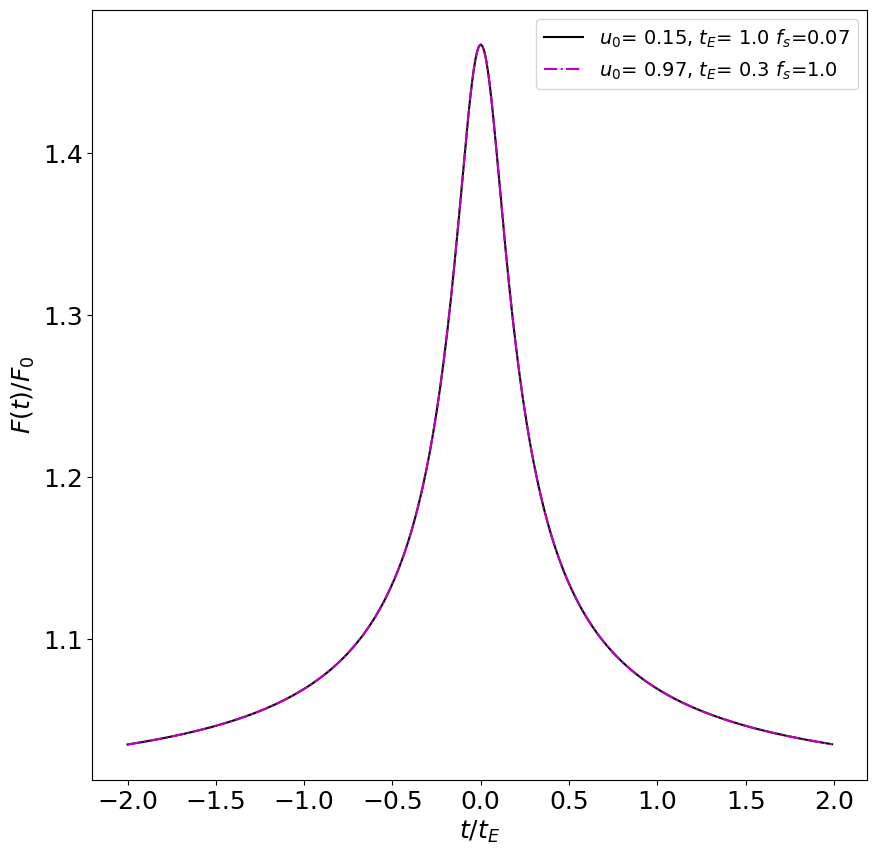

In [25]:
fig, axs = plt.subplots(1, 1, figsize=(10,10))

axs.plot(t, A1, 'k-', label='$u_{0}$= ' + str(u0_1) + ', $t_{E}$= ' + str(tE_1) + ' $f_{s}$=' + str(fratio_1))
axs.plot(t, A2, 'm-.', label='$u_{0}$= ' + str(u0_2) + ', $t_{E}$= ' + str(tE_2) + ' $f_{s}$='+str(fratio_2))

axs.set_xlabel('$t/t_{E}$', fontsize=18)
axs.set_ylabel('$F(t)/F_{0}$', fontsize=18)
axs.tick_params(axis='x', labelsize=18)
axs.tick_params(axis='y', labelsize=18)
axs.legend(loc='upper right', fontsize=14)

#axs.set_ylim((0.0, 40))

plt.savefig('./blending_degen_heavy_blending.png')